In [1]:
import numpy as np

from tools.surface_code import generate_steane_circuit
from tools.error_models import construct_bit_flip_model, construct_basic_noise_model, construct_phase_flip_model
from tools.log_error_rate import generate_log_error_rates_diff_p, count_logical_errors_ML, count_logical_errors_MWPM  
from tools.fssa import compute_critical_exponents, compute_error_bar

In [2]:
import tools.graphics as graphic 
from importlib import reload
reload(graphic)

<module 'tools.graphics' from '/home/leo/Documents/MasterArbeit/code/tools/graphics.py'>

In [3]:
# Global parameters
distances = [5,3,7]
rounds = 1 
noise_set = np.logspace(-1.1,-0.8, num=10)
num_shots = 10_000 
observable = "Z"

steane_circuits = [generate_steane_circuit(d,rounds=rounds,observable=observable) for d in distances]
graphic.save_circuit_diagram(steane_circuits[0],savepath="test_circ.svg")
if observable == "Z":
    error_func = construct_bit_flip_model
    noise_model = "bit_flip"
elif observable == "X":
    error_func = construct_phase_flip_model 
    noise_model = "phase_flip"

In [4]:

# MWMP (Basic Noise)
# count_logical_func = gen_error_model_count_logical_error_MWPM("bit_flip")
count_logical_func = count_logical_errors_MWPM


log_error_rates_MWPM, y_errs_MWPM = generate_log_error_rates_diff_p(
    steane_circuits,
    error_func,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
    rounds=rounds,
    noise_model=noise_model,
    observable=observable
)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2.0940141928013207
             x: [ 1.051e-01  6.275e-01]
           nit: 31
          nfev: 61
 final_simplex: (array([[ 1.051e-01,  6.275e-01],
                       [ 1.051e-01,  6.274e-01],
                       [ 1.051e-01,  6.274e-01]]), array([ 2.094e+00,  2.094e+00,  2.094e+00]))
1.5937425024478333
0.1051025768973808


/home/leo/Documents/MasterArbeit/code/tools/fssa.py:17: RuntimeWarning: invalid value encountered in divide
  y_bar = ((x2 - x1) * y0 - (x0 - x1) * y2) / (x2 - x0)
/home/leo/Documents/MasterArbeit/code/tools/fssa.py:18: RuntimeWarning: invalid value encountered in divide
  delta_sq = (e1**2 + (e0 * (x2 - x1) / (x2 - x0))**2 + (e2 * (x0 - x1) / (x2 - x0))**2)


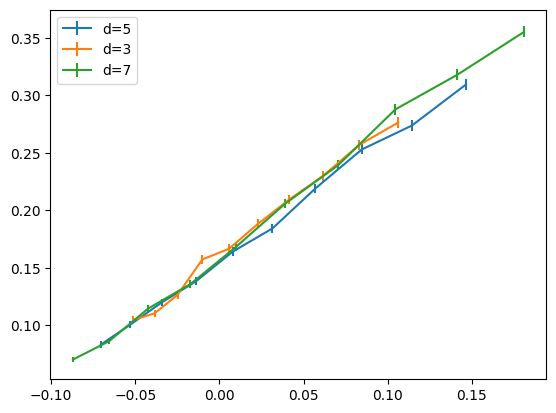

In [5]:
# some tests
xs = [noise_set] * len(distances)
ys = log_error_rates_MWPM 
errs = y_errs_MWPM

guess_pc = 0.1
guess_nu = 1.5 

result = compute_critical_exponents(
    xs_list=xs,
    ys_list=ys,
    errs_list=errs,
    Ls=distances,
    guess_xc=guess_pc,
    guess_nu=guess_nu,
)
print(result)
pc, inv_nu = result.x
nu = 1/inv_nu
print(nu)
print(pc)

graphic.plot_fssa_results(xs,ys,errs,pc,nu,distances)




<Figure size 640x480 with 0 Axes>

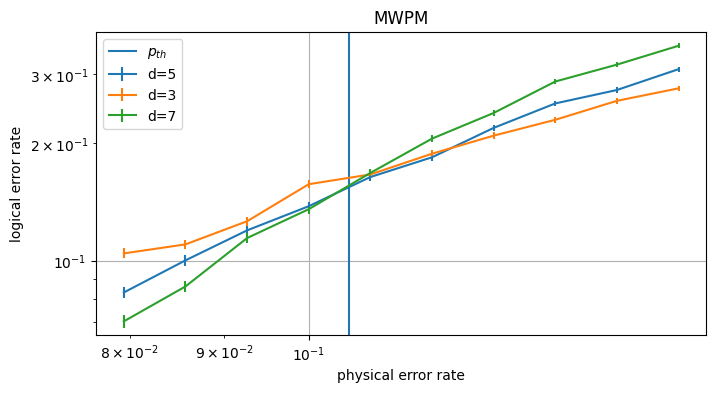

In [6]:

graphic.plot_diff_noise_level(
        log_error_rates_MWPM,
        y_errs_MWPM,
        distances,
        noise_set,
        # fit_slopes = True,
        # reference_lines = True,
        title="MWPM",
        p_th=pc,
    ) 

In [7]:
# ML
count_logical_func = count_logical_errors_ML

log_error_rates_ML, y_errs_ML = generate_log_error_rates_diff_p(
    steane_circuits,
    error_func,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
    rounds=rounds,
    noise_model=noise_model,
    observable=observable
)
# Aron
# baseline 52.3s
# 1. improvement: 37.8s  
# 2. improvement: 28.7s jit half syndrome decoder 

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.32171529797096127
             x: [ 1.055e-01  7.787e-01]
           nit: 36
          nfev: 73
 final_simplex: (array([[ 1.055e-01,  7.787e-01],
                       [ 1.055e-01,  7.787e-01],
                       [ 1.055e-01,  7.787e-01]]), array([ 3.217e-01,  3.217e-01,  3.217e-01]))
1.2842229948241628
0.10551249373436049


/home/leo/Documents/MasterArbeit/code/tools/fssa.py:17: RuntimeWarning: invalid value encountered in divide
  y_bar = ((x2 - x1) * y0 - (x0 - x1) * y2) / (x2 - x0)
/home/leo/Documents/MasterArbeit/code/tools/fssa.py:18: RuntimeWarning: invalid value encountered in divide
  delta_sq = (e1**2 + (e0 * (x2 - x1) / (x2 - x0))**2 + (e2 * (x0 - x1) / (x2 - x0))**2)


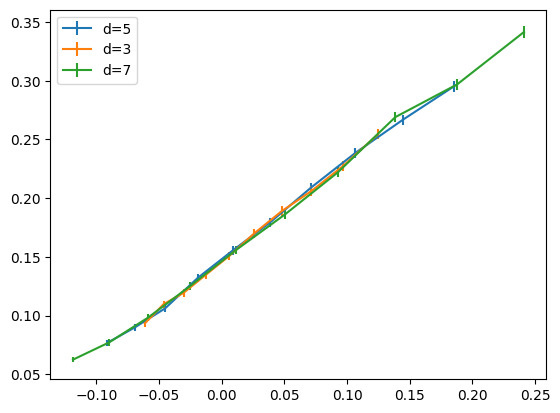

In [8]:
# some tests
xs = [noise_set] * len(distances)
ys = log_error_rates_ML 
errs = y_errs_ML

guess_pc = 0.1
guess_nu = 1.5 

result = compute_critical_exponents(
    xs_list=xs,
    ys_list=ys,
    errs_list=errs,
    Ls=distances,
    guess_xc=guess_pc,
    guess_nu=guess_nu,
)
print(result)
pc, inv_nu = result.x
nu = 1/inv_nu
print(nu)
print(pc)

graphic.plot_fssa_results(xs,ys,errs,pc,nu,distances)

<Figure size 640x480 with 0 Axes>

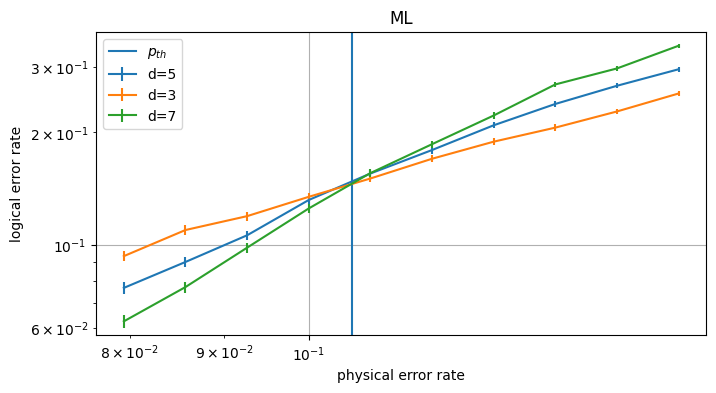

In [9]:
graphic.plot_diff_noise_level(
        log_error_rates_ML,
        y_errs_ML,
        distances,
        noise_set,
        # fit_slopes = True,
        # reference_lines = True,
        title="ML",
        p_th=pc,
    ) 

In [10]:
# # MWPM all knowing using_MWPM 

# # special_circ
# steane_circuits_no_ft = [generate_steane_circuit(d,rounds=rounds,ft_stab_detector=False) for d in distances]


# log_error_rates_MWPM_AK, y_errs_MWPM_AK = generate_log_error_rates_diff_p(
#     steane_circuits_no_ft,
#     error_func,
#     count_log_error_fct=count_logical_func,
#     distances= distances,
#     noise_set= noise_set,
#     num_shots= num_shots,
#     rounds=rounds,
#     noise_model=noise_model,
# )

<Figure size 640x480 with 0 Axes>

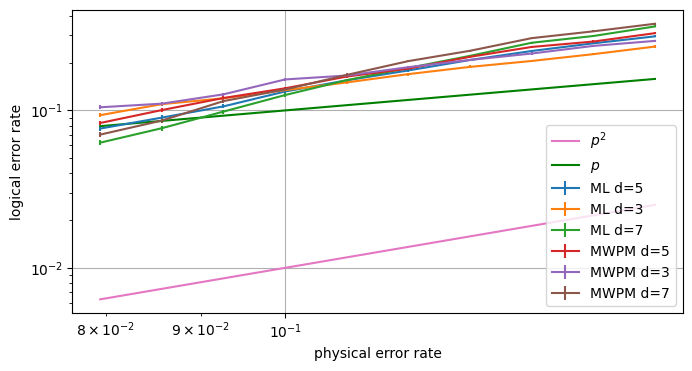

In [11]:
graphic.overlay_different_slopes(
    [log_error_rates_ML, log_error_rates_MWPM, ],
    [y_errs_ML, y_errs_MWPM, ],
    distances=distances,
    noise_set=noise_set,
    titles=["ML", "MWPM", "MWPM (ak)"],
    reference_lines=True,
)

<Figure size 640x480 with 0 Axes>

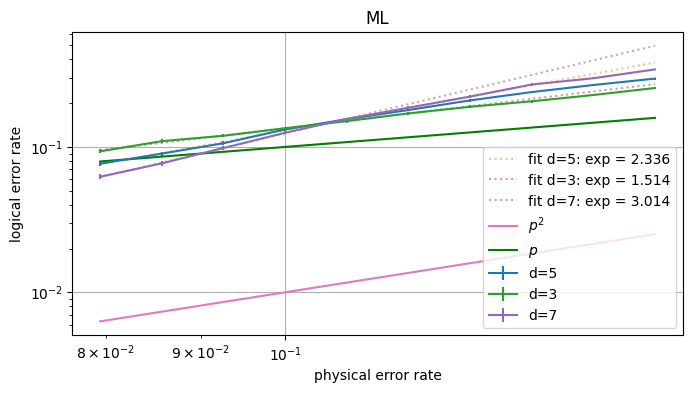

<Figure size 640x480 with 0 Axes>

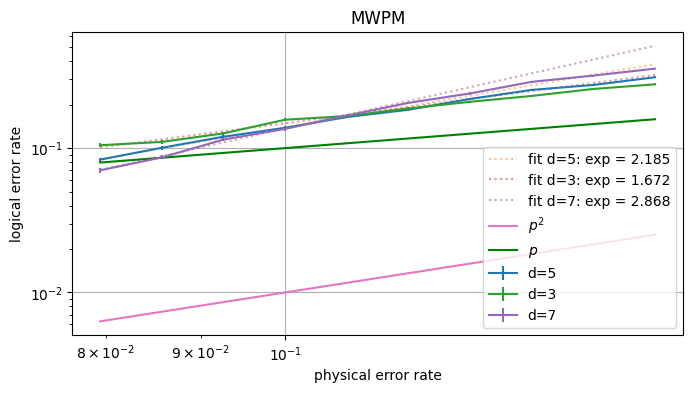

In [12]:
graphic.plot_diff_noise_level(
        log_error_rates_ML,
        y_errs_ML,
        distances,
        noise_set,
        fit_slopes = True,
        reference_lines = True,
        title="ML"
    ) 
graphic.plot_diff_noise_level(
        log_error_rates_MWPM,
        y_errs_MWPM,
        distances,
        noise_set,
        fit_slopes = True,
        reference_lines = True,
        title="MWPM"
    ) 
# graphic.plot_diff_noise_level(
#         log_error_rates_MWPM_AK,
#         y_errs_MWPM_AK,
#         distances,
#         noise_set,
#         fit_slopes = True,
#         reference_lines = True,
#         title="MWPM AK"
#     ) 